In [1]:
# =====================
# TensorFlow / GPU
# =====================
import os

# 只暴露物理 GPU 1 给整个进程
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
print("Visible GPUs to TensorFlow:", gpus)

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print("Default GPU device:", tf.test.gpu_device_name())



# =====================
# Scientific stack
# =====================
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

%matplotlib inline


# =====================
# Mitsuba / DrJit
# =====================
import mitsuba as mi
import drjit as dr


# =====================
# Sionna RT
# =====================
from sionna.rt import (
    load_scene,
    PlanarArray,
    Transmitter,
    Receiver,
    Camera,
    PathSolver,
    ITURadioMaterial,
    SceneObject,
    AntennaPattern,
    register_antenna_pattern,
)


# =====================
# Custom utils / scenes
# =====================
import sionnautils
from sionnautils.custom_scene import list_scenes, get_scene


# =====================
# Project-specific
# =====================
from Engine_V3 import Engine


# =====================
# Misc
# =====================
import json
from pathlib import Path
import yaml


Visible GPUs to TensorFlow: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Default GPU device: /device:GPU:0


I0000 00:00:1772818677.404453  133631 gpu_device.cc:2020] Created device /device:GPU:0 with 14782 MB memory:  -> device: 0, name: Tesla V100-SXM2-16GB, pci bus id: 0000:1e:00.0, compute capability: 7.0


In [2]:
import yaml


def normalize_config(obj):
    """Recursively normalize:
    - numeric strings (incl. scientific notation) -> float
    - 'np.pi', 'np.e', 'np.inf' -> numpy constants
    """
    if isinstance(obj, dict):
        return {k: normalize_config(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [normalize_config(v) for v in obj]

    if isinstance(obj, str):
        s = obj.strip()

        # numpy constants
        if s == "np.pi":
            return np.pi
        if s == "np.e":
            return np.e
        if s in ("np.inf", "inf"):
            return np.inf
        if s in ("-np.inf", "-inf"):
            return -np.inf

        # numeric strings (supports "15.0e9", "200.0e6", "3.5E9", etc.)
        try:
            return float(s)
        except ValueError:
            return obj  # keep as string if not numeric

    return obj  # int/float/bool/None stay as-is


with open("config_rotate_withBody.yaml", "r") as f:
    cfg = yaml.safe_load(f)

cfg = normalize_config(cfg)


In [3]:
scene = load_scene()
engine = Engine(cfg, scene)

In [4]:
step_size = 1
rotation_sinr_map = engine.run_rotation_map(step_size = step_size)

Scanning grid:   0%|          | 0/65341 [00:00<?, ?pt/s]/workspace/ruibin/fc_project/UE_fc_hopping_v2/RT_v3/Engine_V3.py:465: UserWarning: Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.
  self.run_RT()
Scanning grid:   0%|          | 231/65341 [00:14<1:07:06, 16.17pt/s]/workspace/ruibin/fc_project/UE_fc_hopping_v2/RT_v3/Engine_V3.py:205: RuntimeWarning: divide by zero encountered in log10
  return 10.0 * np.log10(linear_values)
Scanning grid: 100%|██████████| 65341/65341 [1:07:46<00:00, 16.07pt/s]


In [5]:
rotation_sinr_map.shape

(361, 181, 4)

[Global color scale] vmin = -14.99 dB, vmax = 50.45 dB


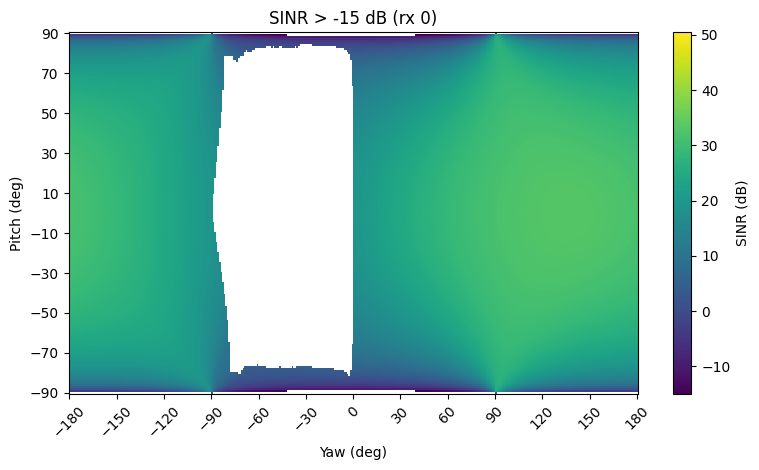

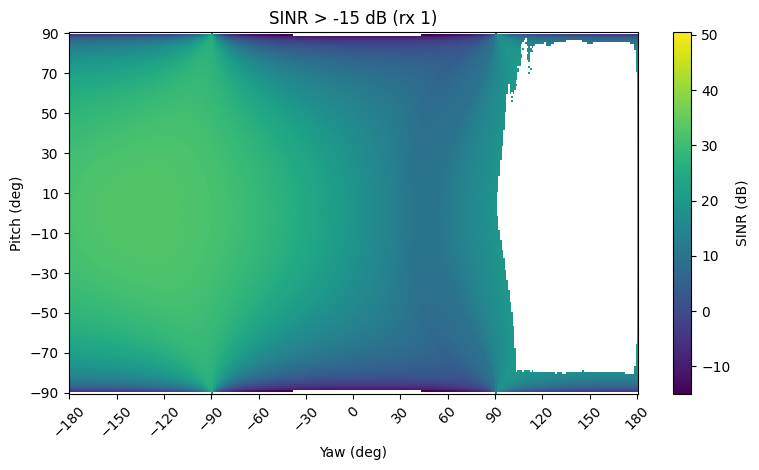

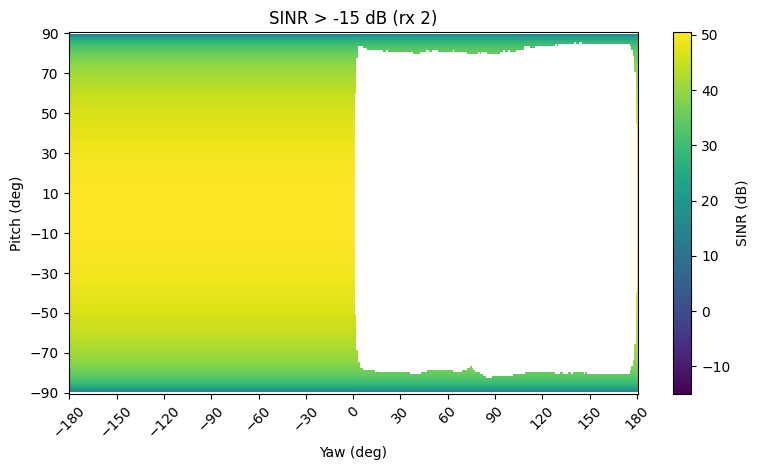

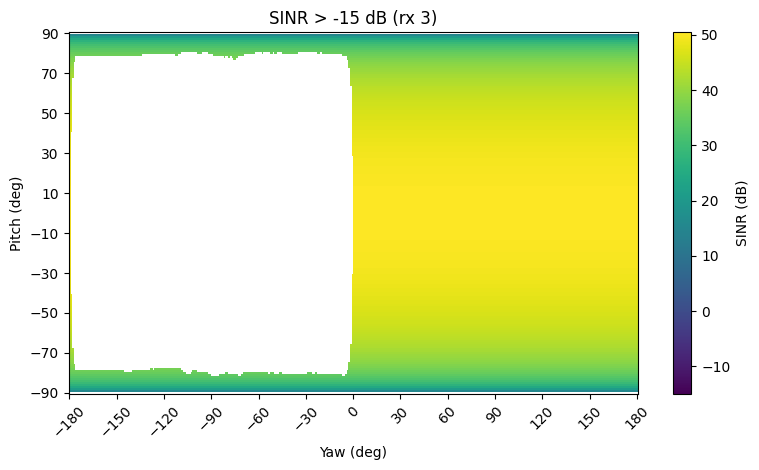

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# basic setup
# =========================
threshold = -15  # dB
tick_every_yaw = 30    # 每隔多少度显示一个 yaw tick
tick_every_pitch = 20  # 每隔多少度显示一个 pitch tick

# rotation_sinr_map: shape (yaw, pitch, rx) or (pitch, yaw, rx)
yaw_deg_list = list(range(-180, 181, step_size))
pitch_deg_list = list(range(-90, 91, step_size))

x_dim = len(yaw_deg_list)
y_dim = len(pitch_deg_list)

assert rotation_sinr_map.shape[:2] in [(x_dim, y_dim), (y_dim, x_dim)], \
    f"shape mismatch: got {rotation_sinr_map.shape}, expected ({x_dim},{y_dim},n_rx) or ({y_dim},{x_dim},n_rx)"

# 统一成 (yaw, pitch, rx)
if rotation_sinr_map.shape[0] == y_dim and rotation_sinr_map.shape[1] == x_dim:
    rotation_sinr_map = np.transpose(rotation_sinr_map, (1, 0, 2))

# =========================
# extent: 像素中心对齐到角度刻度
# =========================
yaw_step = yaw_deg_list[1] - yaw_deg_list[0]
pitch_step = pitch_deg_list[1] - pitch_deg_list[0]

extent = [
    yaw_deg_list[0] - yaw_step / 2,
    yaw_deg_list[-1] + yaw_step / 2,
    pitch_deg_list[0] - pitch_step / 2,
    pitch_deg_list[-1] + pitch_step / 2,
]

# =========================
# 统一 colorbar 范围
# 只考虑 > threshold 的值
# =========================
valid_global = rotation_sinr_map[rotation_sinr_map > threshold]

if valid_global.size == 0:
    raise ValueError(f"No SINR values greater than threshold={threshold} dB.")

global_vmin = valid_global.min()
global_vmax = valid_global.max()

print(f"[Global color scale] vmin = {global_vmin:.2f} dB, vmax = {global_vmax:.2f} dB")

# =========================
# 生成坐标 tick
# =========================
xticks = np.arange(yaw_deg_list[0], yaw_deg_list[-1] + 1, tick_every_yaw)
yticks = np.arange(pitch_deg_list[0], pitch_deg_list[-1] + 1, tick_every_pitch)

# =========================
# plot each rx
# =========================
for rx in range(rotation_sinr_map.shape[2]):
    data = rotation_sinr_map[:, :, rx]   # (yaw, pitch)

    # mask threshold 以下
    data_masked = np.ma.masked_less_equal(data, threshold)

    # imshow 需要 (pitch, yaw)
    img = data_masked.T

    fig, ax = plt.subplots(figsize=(8, 4.8))

    im = ax.imshow(
        img,
        origin="lower",
        aspect="auto",
        extent=extent,
        interpolation="nearest",
        vmin=global_vmin,
        vmax=global_vmax,
    )

    ax.set_title(f"SINR > {threshold} dB (rx {rx})")
    ax.set_xlabel("Yaw (deg)")
    ax.set_ylabel("Pitch (deg)")

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.tick_params(axis="x", labelrotation=45)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("SINR (dB)")

    plt.tight_layout()
    plt.show()

In [7]:
rotation_sinr_map.shape

(361, 181, 4)

In [8]:
rotation_sinr_map[0, np.argmax(rotation_sinr_map[0,:,0]), 0]

31.486528741573938